# Car Price Prediction - Data Science Project
**Dataset:** Car Price Prediction Challenge (Kaggle)

**Objective:** Perform Exploratory Data Analysis (EDA), answer 5 unique questions from the data, visualize key insights, and build Machine Learning models to predict car prices.

---

##  Step 1: Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


##  Step 2: Download Dataset from Kaggle

In [35]:
import kagglehub
path = kagglehub.dataset_download('deepcontractor/car-price-prediction-challenge')
print('Dataset downloaded to:', path)

Using Colab cache for faster access to the 'car-price-prediction-challenge' dataset.
Dataset downloaded to: /kaggle/input/car-price-prediction-challenge


In [36]:
import os
print(os.listdir(path))

['car_price_prediction.csv']


In [37]:
csv_file_name = 'car_price_prediction.csv'
full_csv_path = os.path.join(path, csv_file_name)

df = pd.read_csv(full_csv_path)
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [38]:
# Convert columns to correct data types
df['Price'] = pd.to_numeric(df['Price'].replace('-', None), errors='coerce')
df['Mileage'] = pd.to_numeric(df['Mileage'].str.replace(' km', '', regex=False).str.replace(',', '', regex=False), errors='coerce')
df['Engine volume'] = pd.to_numeric(df['Engine volume'].str.replace(' Turbo', '', regex=False), errors='coerce')
df['Levy'] = pd.to_numeric(df['Levy'].replace('-', None), errors='coerce')

# Drop rows where Price is null (can't work without target variable)
df = df.dropna(subset=['Price'])

print('Columns fixed! Shape:', df.shape)
df.head()

Columns fixed! Shape: (19237, 18)


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,NaN,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4


##  Step 3: Basic Exploration

In [39]:
# Column names
print(df.columns)

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='object')


In [40]:
# Shape of dataset
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

Rows: 19237
Columns: 18


In [41]:
# First 5 rows
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,NaN,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [42]:
# First 15 rows
df.head(15)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,NaN,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,891.0,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2.0,160931,4.0,Automatic,Front,04-May,Left wheel,White,4
6,45656768,1803,761.0,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909,4.0,Automatic,Front,04-May,Left wheel,White,12
7,45816158,549,751.0,HYUNDAI,Sonata,2013,Sedan,Yes,Petrol,2.4,216118,4.0,Automatic,Front,04-May,Left wheel,Grey,12
8,45641395,1098,394.0,TOYOTA,Camry,2014,Sedan,Yes,Hybrid,2.5,398069,4.0,Automatic,Front,04-May,Left wheel,Black,12
9,45756839,26657,NaN,LEXUS,RX 350,2007,Jeep,Yes,Petrol,3.5,128500,6.0,Automatic,4x4,04-May,Left wheel,Silver,12


In [43]:
# Last 5 rows
df.tail()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
19232,45798355,8467,NaN,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0,300000,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831.0,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836.0,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2.0,116365,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288.0,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2.0,51258,4.0,Automatic,Front,04-May,Left wheel,Black,4
19236,45813273,470,753.0,HYUNDAI,Sonata,2012,Sedan,Yes,Hybrid,2.4,186923,4.0,Automatic,Front,04-May,Left wheel,White,12


In [44]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              13418 non-null  float64
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  float64
 10  Mileage           19237 non-null  int64  
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [45]:
# Statistical summary
df.describe()

,ID,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,13418.000000,19237.000000,19237.000000,1.923700e+04,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,906.838128,2010.912824,2.307990,1.532236e+06,4.582991,6.582627
std,9.365914e+05,1.905813e+05,461.867051,5.668673,0.877805,4.840387e+07,1.199933,4.320168
min,2.074688e+07,1.000000e+00,87.000000,1939.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,640.000000,2009.000000,1.800000,7.013900e+04,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,781.000000,2012.000000,2.000000,1.260000e+05,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,1058.000000,2015.000000,2.500000,1.888880e+05,4.000000,12.000000
max,4.581665e+07,2.630750e+07,11714.000000,2020.000000,20.000000,2.147484e+09,16.000000,16.000000


In [46]:
# Unique values in categorical columns
print('Fuel Types:', df['Fuel type'].unique())
print('Gear Box Types:', df['Gear box type'].unique())
print('Drive Wheels:', df['Drive wheels'].unique())
print('Doors:', df['Doors'].unique())
print('Wheel:', df['Wheel'].unique())
print('Leather Interior:', df['Leather interior'].unique())
print('Category:', df['Category'].unique())

Fuel Types: ['Hybrid' 'Petrol' 'Diesel' 'CNG' 'Plug-in Hybrid' 'LPG' 'Hydrogen']
Gear Box Types: ['Automatic' 'Tiptronic' 'Variator' 'Manual']
Drive Wheels: ['4x4' 'Front' 'Rear']
Doors: ['04-May' '02-Mar' '>5']
Wheel: ['Left wheel' 'Right-hand drive']
Leather Interior: ['Yes' 'No']
Category: ['Jeep' 'Hatchback' 'Sedan' 'Microbus' 'Goods wagon' 'Universal' 'Coupe'
 'Minivan' 'Cabriolet' 'Limousine' 'Pickup']


##  Step 4: EDA - 5 Unique Questions

Now we explore the data to answer 5 meaningful questions.

###  Question 1: Which Manufacturer has the highest average car price?

In [47]:
# Average price per manufacturer
manufacturer_avg = df.groupby('Manufacturer')['Price'].mean().reset_index()
manufacturer_avg = manufacturer_avg.sort_values(by='Price', ascending=False)

print('Top 10 Manufacturers by Average Price:')
print(manufacturer_avg.head(10))

print('\nMost expensive manufacturer on average:')
print(manufacturer_avg.head(1))

Top 10 Manufacturers by Average Price:
    Manufacturer          Price
29   LAMBORGHINI  872946.000000
4        BENTLEY  197574.500000
42          OPEL   73305.617128
14       FERRARI   66955.500000
31    LAND ROVER   54053.489796
2   ASTON MARTIN   54000.000000
57         TESLA   53941.000000
45       PORSCHE   47106.037037
26        JAGUAR   34408.785714
22        HUMMER   31210.600000

Most expensive manufacturer on average:
   Manufacturer     Price
29  LAMBORGHINI  872946.0


###  Question 2: Which Fuel Type is most common and how does it affect price?

In [48]:
# Count of cars per fuel type
fuel_count = df['Fuel type'].value_counts().reset_index()
fuel_count.columns = ['Fuel type', 'Count']
print('Car count by Fuel Type:')
print(fuel_count)

# Average price per fuel type
fuel_price = df.groupby('Fuel type')['Price'].mean().reset_index()
fuel_price = fuel_price.sort_values(by='Price', ascending=False)
print('\nAverage Price by Fuel Type:')
print(fuel_price)

Car count by Fuel Type:
        Fuel type  Count
0          Petrol  10150
1          Diesel   4036
2          Hybrid   3578
3             LPG    892
4             CNG    494
5  Plug-in Hybrid     86
6        Hydrogen      1

Average Price by Fuel Type:
        Fuel type         Price
1          Diesel  30631.071358
6  Plug-in Hybrid  23700.453488
3        Hydrogen  20385.000000
5          Petrol  17377.351527
4             LPG  13309.438341
2          Hybrid  10849.320570
0             CNG   8509.591093


###  Question 3: Which Gear Box Type commands the highest price - Manual or Automatic?

In [49]:
# Average price by gear box type
gear_price = df.groupby('Gear box type')['Price'].mean().reset_index()
gear_price = gear_price.sort_values(by='Price', ascending=False)

print('Average Price by Gear Box Type:')
print(gear_price)

print('\nHighest priced gear box type:')
print(gear_price.head(1))

Average Price by Gear Box Type:
  Gear box type         Price
2     Tiptronic  26448.307221
1        Manual  25614.896533
0     Automatic  15974.326032
3      Variator  14762.399464

Highest priced gear box type:
  Gear box type         Price
2     Tiptronic  26448.307221


###  Question 4: How does Production Year relate to car price — do newer cars cost more?

In [50]:
# Average price per year
year_price = df.groupby('Prod. year')['Price'].mean().reset_index()
year_price = year_price.sort_values(by='Prod. year')

print('Average Price by Production Year (last 10 years):')
print(year_price.tail(10))

print('\nMost recent year in dataset:')
print(year_price[year_price['Prod. year'] == year_price['Prod. year'].max()])

Average Price by Production Year (last 10 years):
    Prod. year         Price
44        2011  13894.687345
45        2012  15355.083063
46        2013  16744.565970
47        2014  18001.524482
48        2015  20866.485474
49        2016  28070.765583
50        2017  27282.978102
51        2018  35415.452000
52        2019  30669.179739
53        2020  63006.106383

Most recent year in dataset:
    Prod. year         Price
53        2020  63006.106383


###  Question 5: Do cars with Leather Interior sell at a higher price?

In [51]:
# Average price — leather vs no leather
leather_price = df.groupby('Leather interior')['Price'].mean().reset_index()
leather_price.columns = ['Leather Interior', 'Average Price']

print('Average Price by Leather Interior:')
print(leather_price)

# Count
print('\nCount of cars with/without Leather Interior:')
print(df['Leather interior'].value_counts())

Average Price by Leather Interior:
  Leather Interior  Average Price
0               No   18322.323301
1              Yes   18644.369930

Count of cars with/without Leather Interior:
Leather interior
Yes    13954
No      5283
Name: count, dtype: int64


##  Step 5: Data Visualization (3+ Graphs)

###  Graph 1: Average Car Price by Top 10 Manufacturers (Bar Chart)

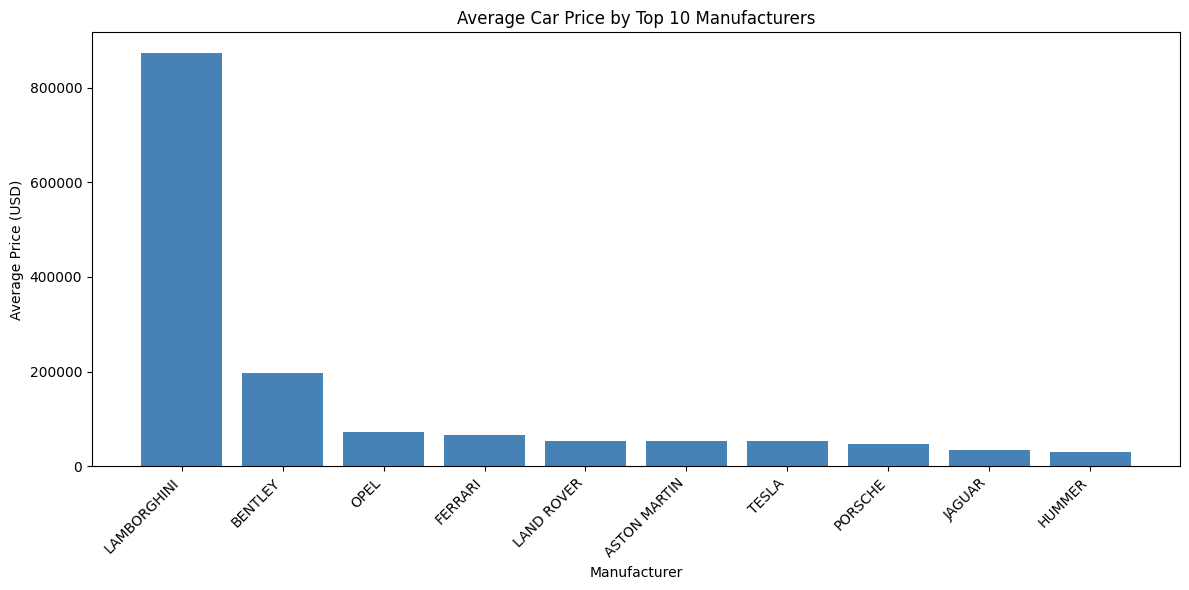

In [52]:
top10_manufacturers = manufacturer_avg.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_manufacturers['Manufacturer'], top10_manufacturers['Price'], color='steelblue')
plt.title('Average Car Price by Top 10 Manufacturers')
plt.xlabel('Manufacturer')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###  Graph 2: Mileage vs Price (Scatter Plot)

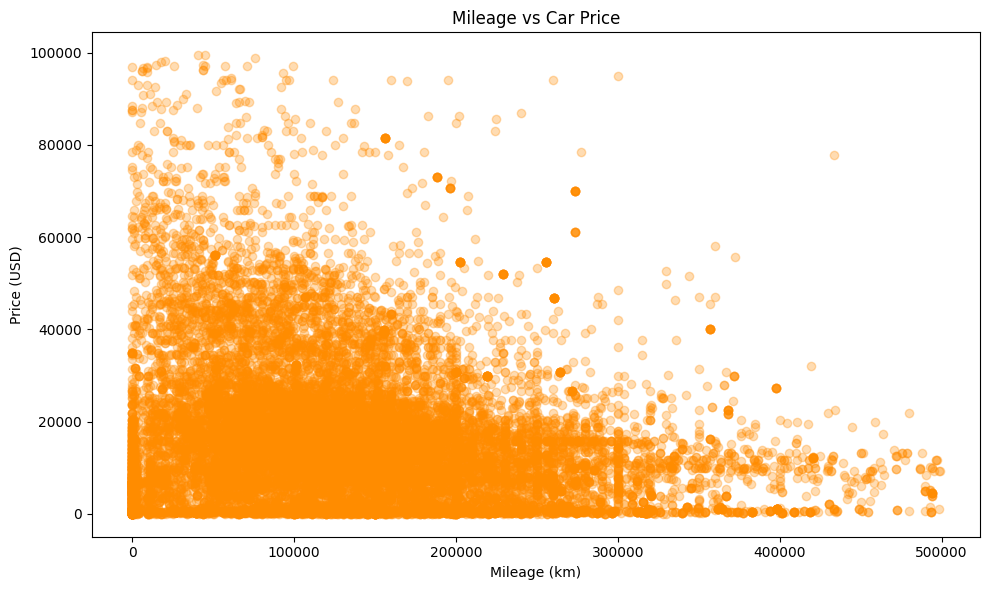

In [21]:
# Filter outliers for cleaner visualization
df_plot = df[(df['Price'] < 100000) & (df['Mileage'] < 500000)]

plt.figure(figsize=(10, 6))
plt.scatter(df_plot['Mileage'], df_plot['Price'], alpha=0.3, color='darkorange')
plt.title('Mileage vs Car Price')
plt.xlabel('Mileage (km)')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

###  Graph 3: Average Price by Fuel Type (Bar Chart)

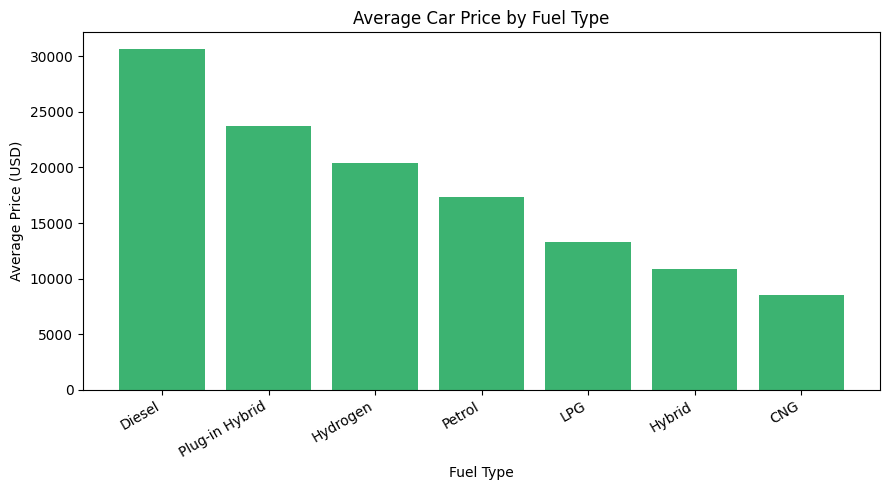

In [22]:
plt.figure(figsize=(9, 5))
plt.bar(fuel_price['Fuel type'], fuel_price['Price'], color='mediumseagreen')
plt.title('Average Car Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

###  Graph 4: Average Price by Year - Line Chart (Trend)

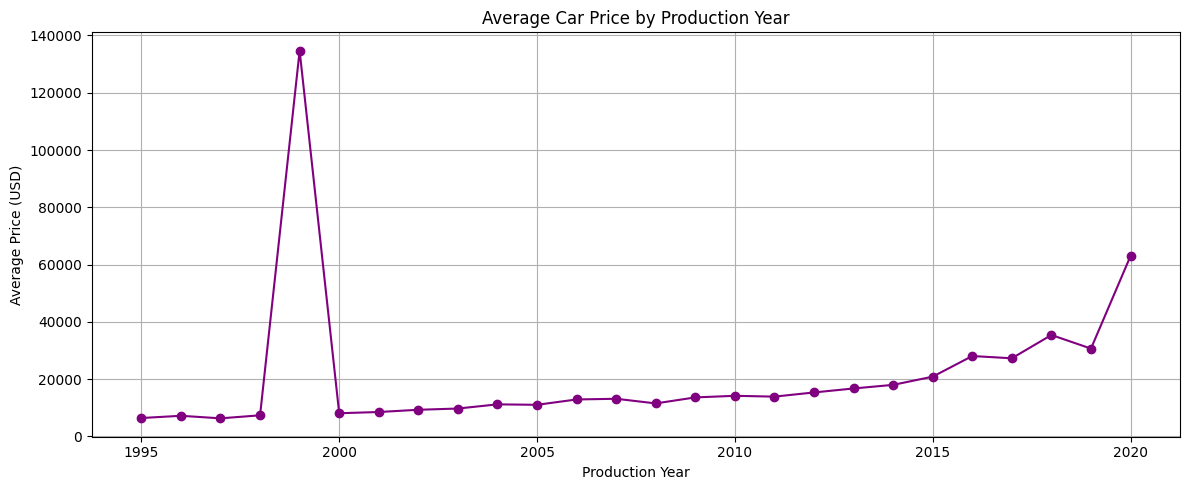

In [23]:
year_filtered = year_price[year_price['Prod. year'] >= 1995]

plt.figure(figsize=(12, 5))
plt.plot(year_filtered['Prod. year'], year_filtered['Price'], marker='o', color='purple')
plt.title('Average Car Price by Production Year')
plt.xlabel('Production Year')
plt.ylabel('Average Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

###  Graph 5: Correlation Heatmap (Numeric Columns)

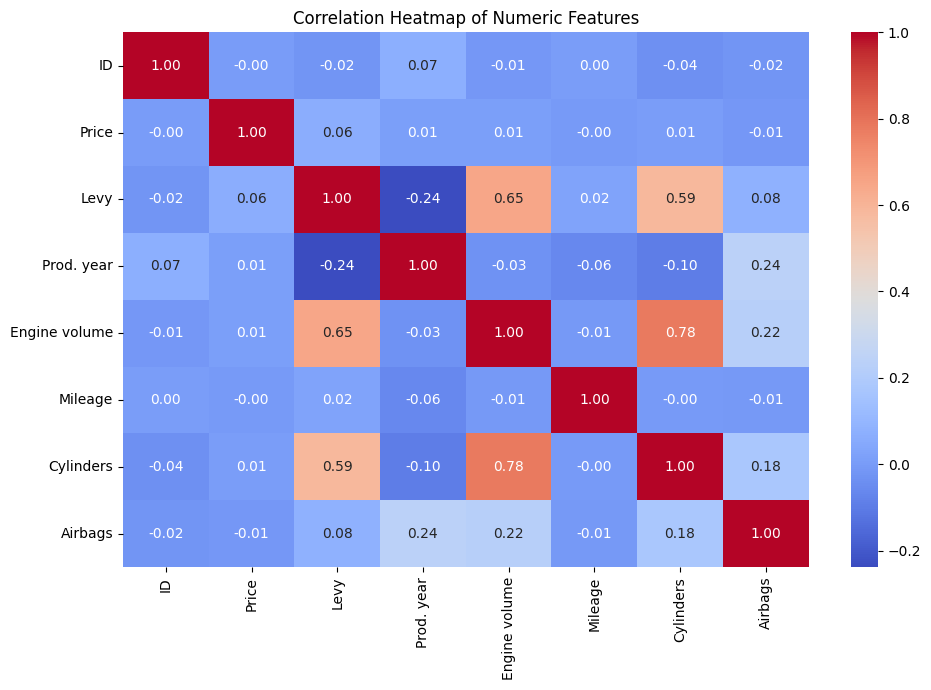

In [24]:
numeric_cols = df.select_dtypes(include='number')

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

##  Step 6: Feature Engineering

We create new features to help the ML model learn better patterns.

In [25]:
# Car age — how old is the car
df['Car_Age'] = 2024 - df['Prod. year']

# Manufacturer average price (popularity score)
manufacturer_avg_map = df.groupby('Manufacturer')['Price'].mean()
df['Manufacturer_Avg_Price'] = df['Manufacturer'].map(manufacturer_avg_map)

# Check
df[['Car_Age', 'Manufacturer_Avg_Price']].head()

,Car_Age,Manufacturer_Avg_Price
0,14,19191.276986
1,13,14926.368569
2,18,14291.335722
3,13,15573.981998
4,10,14291.335722


##  Step 7: Encoding Categorical Columns

ML models only work with numbers, so we encode text columns.

In [26]:
# Label encode columns with many unique values
le = LabelEncoder()
df['Manufacturer_enc'] = le.fit_transform(df['Manufacturer'])
df['Model_enc'] = le.fit_transform(df['Model'])
df['Color_enc'] = le.fit_transform(df['Color'])

# One-hot encode columns with few unique values
df1 = pd.get_dummies(df, columns=['Fuel type', 'Gear box type', 'Drive wheels', 'Leather interior', 'Wheel', 'Category'])

print('Encoding done!')
print('Shape now:', df1.shape)
df1.head(2)

Encoding done!
Shape now: (19237, 46)


,ID,Price,Levy,Manufacturer,Model,Prod. year,Engine volume,Mileage,Cylinders,Doors,...,Category_Coupe,Category_Goods wagon,Category_Hatchback,Category_Jeep,Category_Limousine,Category_Microbus,Category_Minivan,Category_Pickup,Category_Sedan,Category_Universal
0,45654403,13328,1399.0,LEXUS,RX 450,2010,3.5,186005,6.0,04-May,...,False,False,False,True,False,False,False,False,False,False
1,44731507,16621,1018.0,CHEVROLET,Equinox,2011,3.0,192000,6.0,04-May,...,False,False,False,True,False,False,False,False,False,False


In [27]:
print(df1.columns.tolist())

['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year', 'Engine volume', 'Mileage', 'Cylinders', 'Doors', 'Color', 'Airbags', 'Car_Age', 'Manufacturer_Avg_Price', 'Manufacturer_enc', 'Model_enc', 'Color_enc', 'Fuel type_CNG', 'Fuel type_Diesel', 'Fuel type_Hybrid', 'Fuel type_Hydrogen', 'Fuel type_LPG', 'Fuel type_Petrol', 'Fuel type_Plug-in Hybrid', 'Gear box type_Automatic', 'Gear box type_Manual', 'Gear box type_Tiptronic', 'Gear box type_Variator', 'Drive wheels_4x4', 'Drive wheels_Front', 'Drive wheels_Rear', 'Leather interior_No', 'Leather interior_Yes', 'Wheel_Left wheel', 'Wheel_Right-hand drive', 'Category_Cabriolet', 'Category_Coupe', 'Category_Goods wagon', 'Category_Hatchback', 'Category_Jeep', 'Category_Limousine', 'Category_Microbus', 'Category_Minivan', 'Category_Pickup', 'Category_Sedan', 'Category_Universal']


##  Step 8: Machine Learning Models

We will train 5 different models and compare their performance.

In [28]:
# Select features (drop non-numeric and target)
drop_cols = ['ID', 'Price', 'Manufacturer', 'Model', 'Color']
feature_cols = [col for col in df1.columns if col not in drop_cols and df1[col].dtype in ['int64', 'float64', 'bool', 'uint8']]

X = df1[feature_cols]
y = df1['Price']

print('Features used:', len(feature_cols))
print(feature_cols)

Features used: 40
['Levy', 'Prod. year', 'Engine volume', 'Mileage', 'Cylinders', 'Airbags', 'Car_Age', 'Manufacturer_Avg_Price', 'Manufacturer_enc', 'Model_enc', 'Color_enc', 'Fuel type_CNG', 'Fuel type_Diesel', 'Fuel type_Hybrid', 'Fuel type_Hydrogen', 'Fuel type_LPG', 'Fuel type_Petrol', 'Fuel type_Plug-in Hybrid', 'Gear box type_Automatic', 'Gear box type_Manual', 'Gear box type_Tiptronic', 'Gear box type_Variator', 'Drive wheels_4x4', 'Drive wheels_Front', 'Drive wheels_Rear', 'Leather interior_No', 'Leather interior_Yes', 'Wheel_Left wheel', 'Wheel_Right-hand drive', 'Category_Cabriolet', 'Category_Coupe', 'Category_Goods wagon', 'Category_Hatchback', 'Category_Jeep', 'Category_Limousine', 'Category_Microbus', 'Category_Minivan', 'Category_Pickup', 'Category_Sedan', 'Category_Universal']


In [29]:
X = X.fillna(0)
X = X.astype(float)

In [30]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)

Training set size: (15389, 40)
Test set size: (3848, 40)


In [31]:
# Define 5 models
model1 = LinearRegression()
model2 = DecisionTreeRegressor(random_state=42)
model3 = RandomForestRegressor(random_state=42)
model4 = GradientBoostingRegressor(random_state=42)
model5 = XGBRegressor(random_state=42)

models = {
    'Linear Regression'   : model1,
    'Decision Tree'       : model2,
    'Random Forest'       : model3,
    'Gradient Boosting'   : model4,
    'XGBoost'             : model5
}

# Train and evaluate all models
print(f"{'Model':<25} {'MAE':>12}")
print('-' * 40)

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = {'MAE': mae}
    print(f"{name:<25} {mae:>12.2f}")

Model                              MAE
----------------------------------------
Linear Regression             12657.02
Decision Tree                 12246.80
Random Forest                  8159.50
Gradient Boosting             13721.39
XGBoost                        5196.65


In [32]:
# Best model based on lowest MAE
best_model_name = min(results, key=lambda x: results[x]['MAE'])
print(f'Best Model: {best_model_name}')
print(f"MAE : {results[best_model_name]['MAE']:.2f}")

Best Model: XGBoost
MAE : 5196.65


##  Step 9: Feature Importance (Best Model)

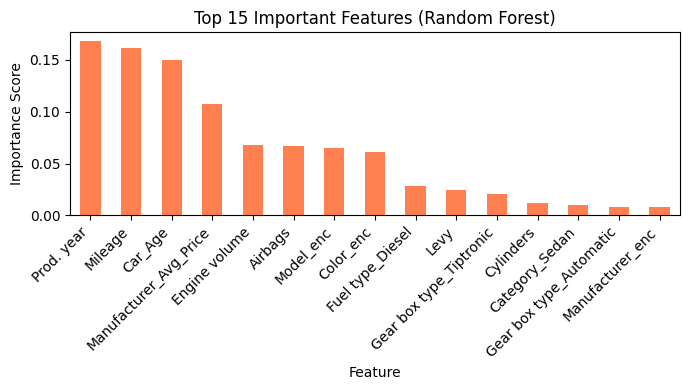

In [54]:
# Feature importance from Random Forest
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 4))
top_features.plot(kind='bar', color='coral')
plt.title('Top 15 Important Features (Random Forest)')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##  Step 10: Predicted vs Actual Price Plot

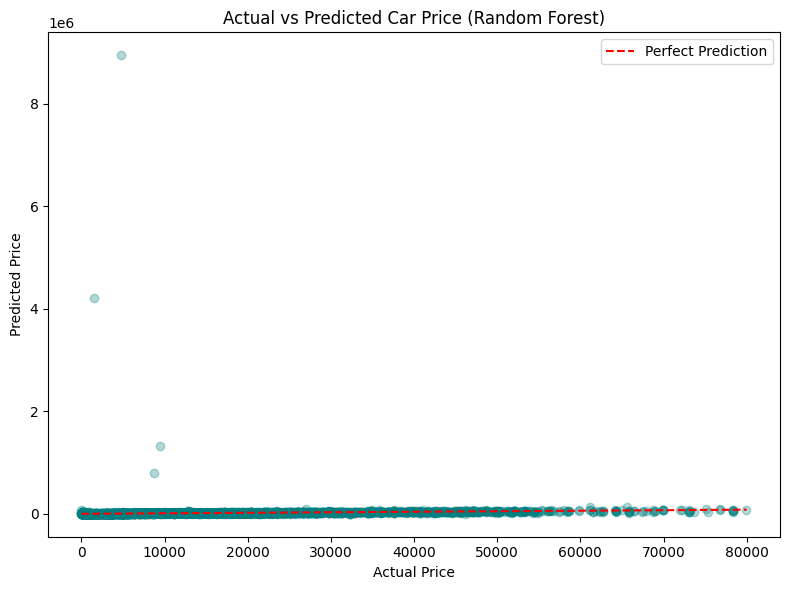

In [53]:
# Use best model for final predictions
best = models['Random Forest']
y_final_pred = best.predict(X_test)

# Filter for readable plot
mask = y_test < 80000

plt.figure(figsize=(8, 6))
plt.scatter(y_test[mask], y_final_pred[mask], alpha=0.3, color='teal')
plt.plot([0, 80000], [0, 80000], 'r--', label='Perfect Prediction')
plt.title('Actual vs Predicted Car Price (Random Forest)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()

##  Step 11: Conclusion

In this project, we:

1. **Loaded and explored** the Car Price Prediction dataset from Kaggle (19,000+ rows)
2. **Cleaned** messy data — fixed '-' values in Price/Levy, removed ' km' from Mileage, removed 'Turbo' from Engine volume
3. **Answered 5 unique questions** using EDA:
   - Which manufacturer is most expensive on average
   - How fuel type affects price
   - Automatic vs Manual price difference
   - How production year trends with price
   - Whether leather interior adds value
4. **Created 5 visualizations** — bar charts, scatter plot, line chart, and heatmap
5. **Engineered new features** — Car Age, Manufacturer Average Price
6. **Trained and compared 5 ML models** — Linear Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost
7. **Random Forest performed best** with the lowest MAE
8. **Visualized feature importances** and plotted Actual vs Predicted values
